In [19]:
# I used Github's Copilot to assist in debugging problems I had writing this code. I also extensively used Google for help on specific functions and methods, such as creating better, readable graphs with matplotlib.
import geopandas as gpd
import pandas as pd
import numpy as np
import rioxarray as rio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [20]:
usa_counties = gpd.read_file(r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\tl_2025_us_county\tl_2025_us_county.shp")
baldwin = usa_counties[usa_counties['GEOID'] == '01003']

years = [2015, 2019, 2022, 2025]
# Green is Band 3, Red is Band 4, NIR is Band 5, and SWIR is Band 6. Don't have to use the blue band (Band 2).
landsat_data = {
    2015: {
        "green": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2015\LC08_L2SP_020039_20150124_20200910_02_T1_SR_B3.TIF",
        "red": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2015\LC08_L2SP_020039_20150124_20200910_02_T1_SR_B4.TIF",
        "nir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2015\LC08_L2SP_020039_20150124_20200910_02_T1_SR_B5.TIF",
        "swir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2015\LC08_L2SP_020039_20150124_20200910_02_T1_SR_B6.TIF",
    },
    2019: {
        "green": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2019\LC08_L2SP_020039_20191119_20200825_02_T1_SR_B3.TIF",
        "red": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2019\LC08_L2SP_020039_20191119_20200825_02_T1_SR_B4.TIF",
        "nir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2019\LC08_L2SP_020039_20191119_20200825_02_T1_SR_B5.TIF",
        "swir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2019\LC08_L2SP_020039_20191119_20200825_02_T1_SR_B6.TIF",
    },
    2022: {
    "green": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2022\LC08_L2SP_020039_20221026_20221107_02_T1_SR_B3.TIF",
    "red": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2022\LC08_L2SP_020039_20221026_20221107_02_T1_SR_B4.TIF",
    "nir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2022\LC08_L2SP_020039_20221026_20221107_02_T1_SR_B5.TIF",
    "swir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2022\LC08_L2SP_020039_20221026_20221107_02_T1_SR_B6.TIF",
    },
    2025: {
        "green": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2025\LC09_L2SP_020039_20251127_20251129_02_T1_SR_B3.TIF",
        "red": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2025\LC09_L2SP_020039_20251127_20251129_02_T1_SR_B4.TIF",
        "nir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2025\LC09_L2SP_020039_20251127_20251129_02_T1_SR_B5.TIF",
        "swir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2025\LC09_L2SP_020039_20251127_20251129_02_T1_SR_B6.TIF",
    }
}
# Use the file path 'C:\Users\asanders\Documents\' when in the computer lab
# Use the file path 'C:\Users\andre\OneDrive\Documents\schoolstuff\' when on laptop

In [21]:
def classify_land_cover(ndvi, ndwi, ndbi):
    """
    This function determines land use land cover (LULC) using NDVI, NDWI, and NDBI threshold values.

    Parameters:
    -----------------
    ndvi: numpy.ndarray
    An array for Normalized Difference Vegetation Index. Higher NDVI values indicate a parcel of land has dense vegetation.

    ndwi: numpy.ndarray
    An array for Normalized Difference Water Index. Higher NDWI values indicate a region has bodies of water such as rivers, ponds, and lakes.

    ndbi: numpy.ndarray
    An array for Normalized Difference Built-up Index. Higher NDBI values indicate an area is "built-up", in other words, urbanized.

    Returns:
    -----------------
    numpy.ndarray
        An array of classified LULC with the following labels:
            0: Vegetation
            1: Built-up
            2: Water
    """
    lulc = np.full(ndvi.shape, np.nan) # creates a new array with the same dimension as the ndvi array and fills it with NaN values
    
    # Water classification
    lulc = np.where(ndwi > 0.3, 2, lulc) # #np.where is basically like an if statement. If a pixel has NDWI > 0.3, then it gets labeled as water (2). If not, then the pixel remains unclassified.

    # Vegetation classification
    lulc = np.where(ndvi > 0.4, 0, lulc)

    # Urban classification
    lulc = np.where(ndbi > 0.05, 1, lulc)
    
    return lulc

In [22]:
def load_and_process_bands(year):
    """
    This function reads the red, green, NIR, and SWIR bands for a given year, applies a scaling factor, and clips the data to the borders of Baldwin County.

    Parameters: 
    -----------------
    year: int
        The year for which the bands will be processed. Must be one of the following: 2015, 2019, 2022, or 2025.

    Returns:
    -----------------
    red: xarray.DataArray
    The processed red band for the specified year.
    
    green: xarray.DataArray
    The processed green band for the specified year.

    nir: xarray.DataArray
    The processed NIR band for the specified year.

    swir: xarray.DataArray
    The processed SWIR band for the specified year.
    """
    bands = landsat_data[year]
    
    red = rio.open_rasterio(bands["red"], masked=True).squeeze()
    nir = rio.open_rasterio(bands["nir"], masked=True).squeeze()
    green = rio.open_rasterio(bands["green"], masked=True).squeeze()
    swir = rio.open_rasterio(bands["swir"], masked=True).squeeze()
    
    # Convert to reflectance values
    red = red * 0.0000275 - 0.2
    nir = nir * 0.0000275 - 0.2
    green = green * 0.0000275 - 0.2
    swir = swir * 0.0000275 - 0.2
    
    baldwin_reprojected = baldwin.to_crs(red.rio.crs)
    red = red.rio.clip(baldwin_reprojected.geometry).astype("float32") # float32 to reduce memory usage
    nir = nir.rio.clip(baldwin_reprojected.geometry).astype("float32")
    green = green.rio.clip(baldwin_reprojected.geometry).astype("float32")
    swir = swir.rio.clip(baldwin_reprojected.geometry).astype("float32")
    
    return red, nir, green, swir

In [23]:
classified_maps = {} # Dictionary to hold the classified LULC maps for each year
urban_percent = [] # List to hold the percentage of urbanized land for each year

In [24]:
for year in years:
    red, nir, green, swir = load_and_process_bands(year)
    
    ndvi = (nir - red) / (nir + red)
    ndwi = (green - swir) / (green + swir)
    ndbi = (swir - nir) / (swir + nir)
    
    classified = classify_land_cover(ndvi, ndwi, ndbi)
    classified_maps[year] = classified
    
    # Calculate urban percentage
    valid_pixels = ~np.isnan(classified) # Basically, this creates an array where valid pixels within the borders of Baldwin County are marked as True while pixels outside the borders are marked as False. From what I googled, the tilda operator inverts the boolean values in the array, so valid pixels will be True and invalid pixels will be False.
    urban_pixels = np.sum(classified[valid_pixels] == 1)
    total_pixels = np.sum(valid_pixels)
    percent = (urban_pixels / total_pixels) * 100
    urban_percent.append(percent)
    
    print(f"{year}: {percent:.2f}% urban")

2015: 16.46% urban
2019: 15.79% urban
2022: 18.28% urban
2025: 20.85% urban


In [25]:
# Calculate urban area in 2015 and 2025
pixel_area = (30 * 30)/1000000 # km²

urban_pixels_2015 = np.sum(classified_maps[2015] == 1)
urban_area_2015_km2 = urban_pixels_2015 * pixel_area
urban_area_2015_sqmi = (urban_pixels_2015 * pixel_area)/2.59 # converts to sq mi
print(f"Urban Area in 2015: {urban_area_2015_km2:.2f} km2")
print(f"Urban Area in 2015: {urban_area_2015_sqmi:.2f} sq mi")

urban_pixels_2025 = np.sum(classified_maps[2025] == 1)
urban_area_2025_km2 = urban_pixels_2025 * pixel_area
urban_area_2025_sqmi = (urban_pixels_2025 * pixel_area)/2.59
print(f"Urban Area in 2025: {urban_area_2025_km2:.2f} km2")
print(f"Urban Area in 2025: {urban_area_2025_sqmi:.2f} sq mi")

percent_increase_km2 = ((urban_area_2025_km2 - urban_area_2015_km2)/urban_area_2015_km2)*100
print(f"Since 2015, urban areas have increased by {percent_increase_km2:.2f}%")

veg_pixels_2015 = np.sum(classified_maps[2015] == 0)
veg_area_2015_km2 = veg_pixels_2015 * pixel_area
veg_area_2015_sqmi = (veg_pixels_2015 * pixel_area)/2.59 # converts to sq mi
print(f"Vegetation Area in 2015: {veg_area_2015_km2:.2f} km2")
print(f"Vegetation Area in 2015: {veg_area_2015_sqmi:.2f} sq mi")

veg_pixels_2025 = np.sum(classified_maps[2025] == 0)
veg_area_2025_km2 = veg_pixels_2025 * pixel_area
veg_area_2025_sqmi = (veg_pixels_2025 * pixel_area)/2.59
print(f"Vegetation Area in 2025: {veg_area_2025_km2:.2f} km2")
print(f"Vegetation Area in 2025: {veg_area_2025_sqmi:.2f} sq mi")

percent_increase_km2 = ((veg_area_2025_km2 - veg_area_2015_km2)/veg_area_2015_km2)*100
print(f"Since 2015, vegetation areas have increased by {percent_increase_km2:.2f}%")

Urban Area in 2015: 756.12 km2
Urban Area in 2015: 291.94 sq mi
Urban Area in 2025: 951.64 km2
Urban Area in 2025: 367.43 sq mi
Since 2015, urban areas have increased by 25.86%
Vegetation Area in 2015: 3108.82 km2
Vegetation Area in 2015: 1200.32 sq mi
Vegetation Area in 2025: 3013.50 km2
Vegetation Area in 2025: 1163.51 sq mi
Since 2015, vegetation areas have increased by -3.07%


In [26]:
cmap = mcolors.ListedColormap(["green", "gray", "blue"])
labels = ["Vegetation (0)", "Urban (1)", "Water (2)"]

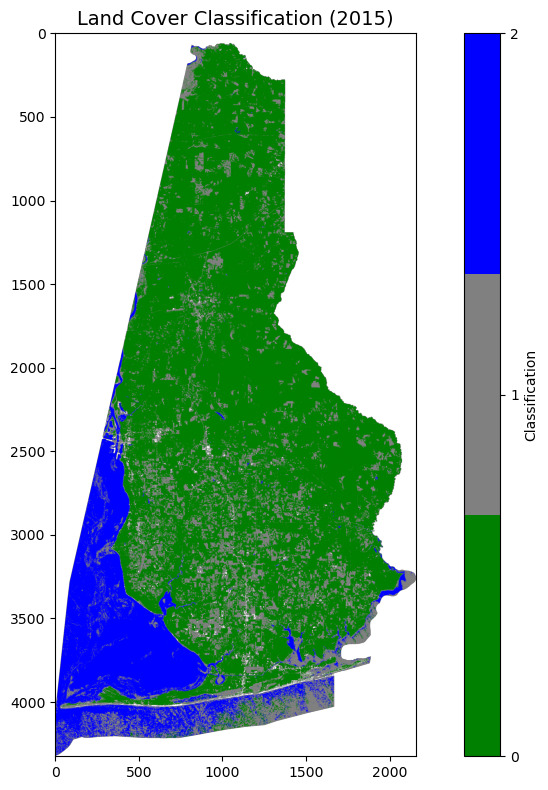

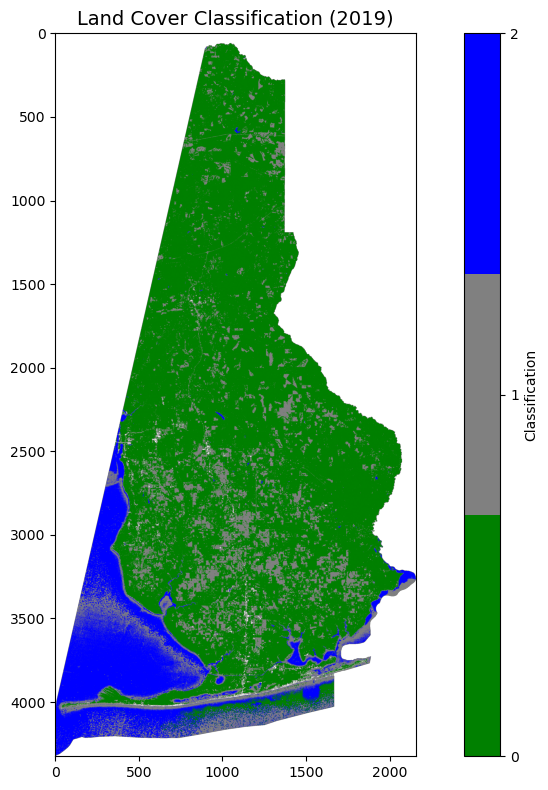

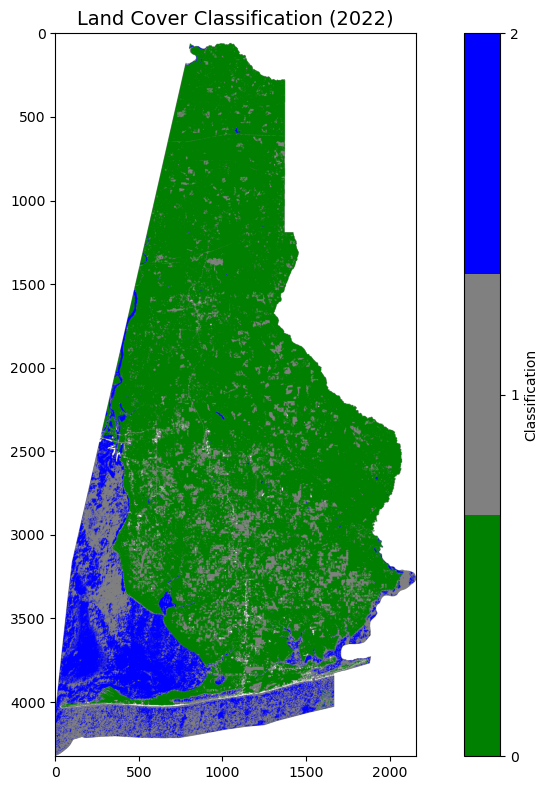

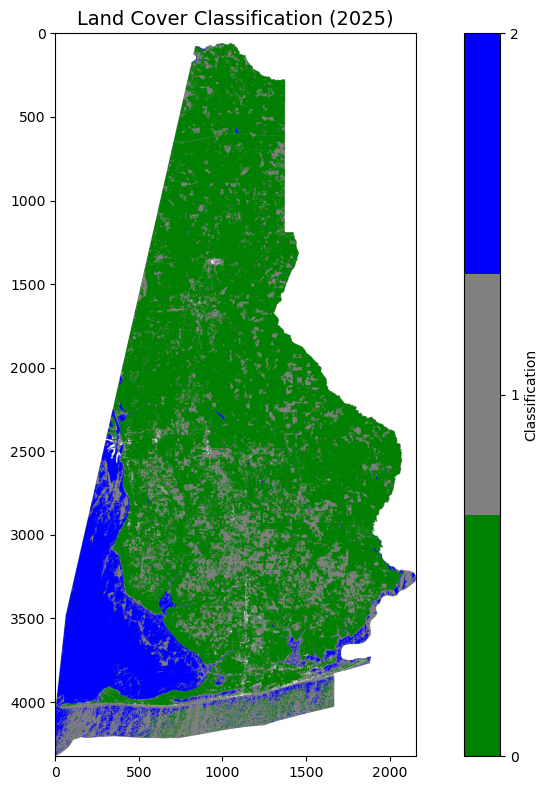

In [27]:
for year in years:
    plt.figure(figsize=(10, 8))
    plt.imshow(classified_maps[year], cmap=cmap, vmin=0, vmax=2)
    plt.title(f"Land Cover Classification ({year})", fontsize=14)
    plt.colorbar(ticks=[0, 1, 2], label="Classification")
    plt.tight_layout()
    plt.show()

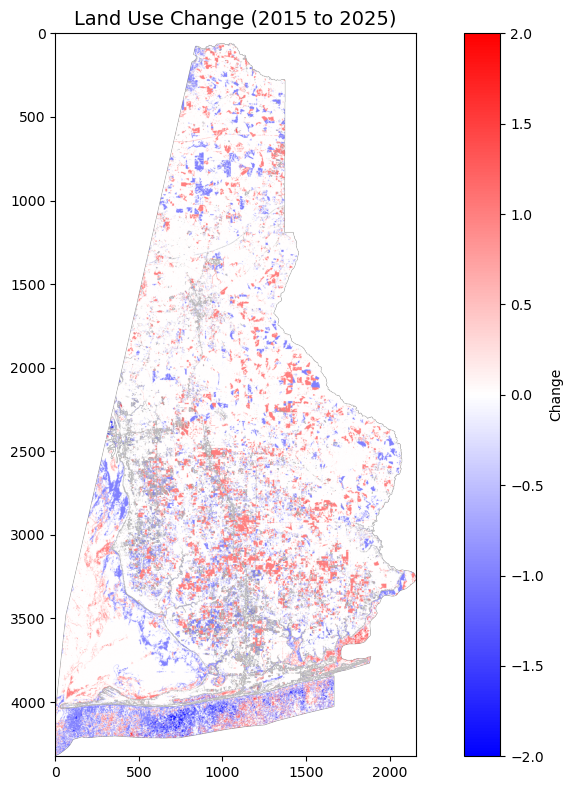

In [28]:
decade_change = classified_maps[2025] - classified_maps[2015]
plt.figure(figsize=(10, 8))
plt.imshow(decade_change, cmap="bwr")
plt.title("Land Use Change (2015 to 2025)", fontsize=14)
plt.colorbar(label="Change")
plt.tight_layout()
plt.show()

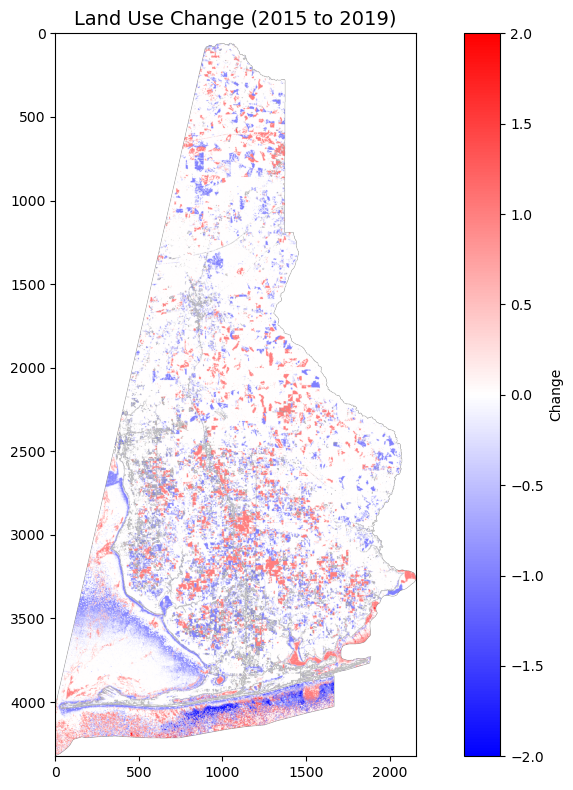

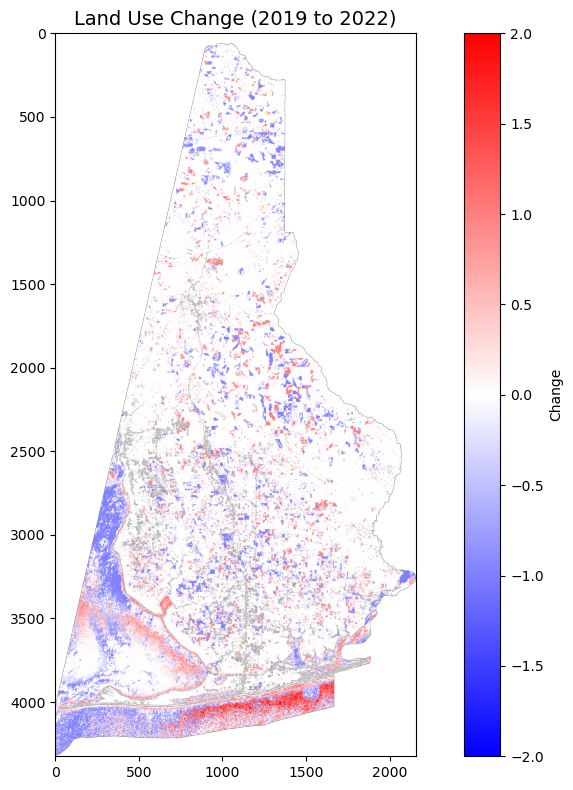

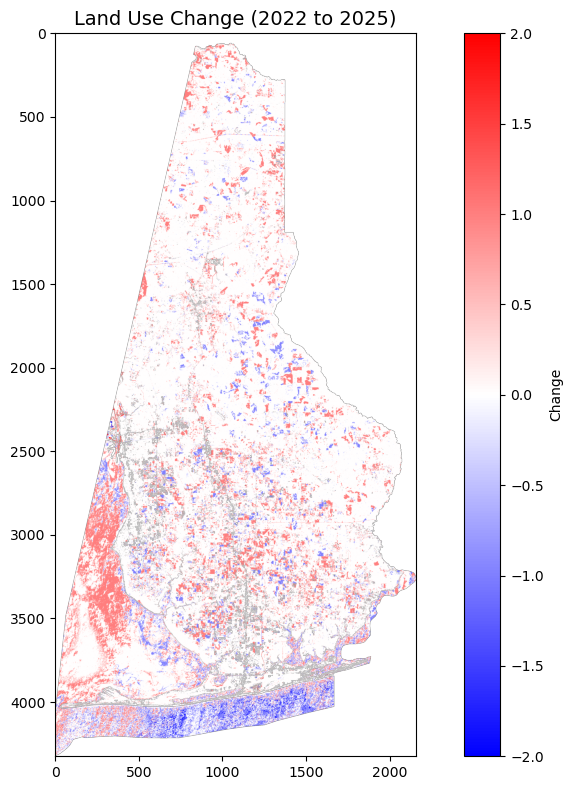

In [29]:
changes = [
    (2015, 2019, classified_maps[2019] - classified_maps[2015]),
    (2019, 2022, classified_maps[2022] - classified_maps[2019]),
    (2022, 2025, classified_maps[2025] - classified_maps[2022]),
]

for year1, year2, change in changes:
    plt.figure(figsize=(10, 8))
    plt.imshow(change, cmap="bwr")
    plt.title(f"Land Use Change ({year1} to {year2})", fontsize=14)
    plt.colorbar(label="Change")
    plt.tight_layout()
    plt.show()

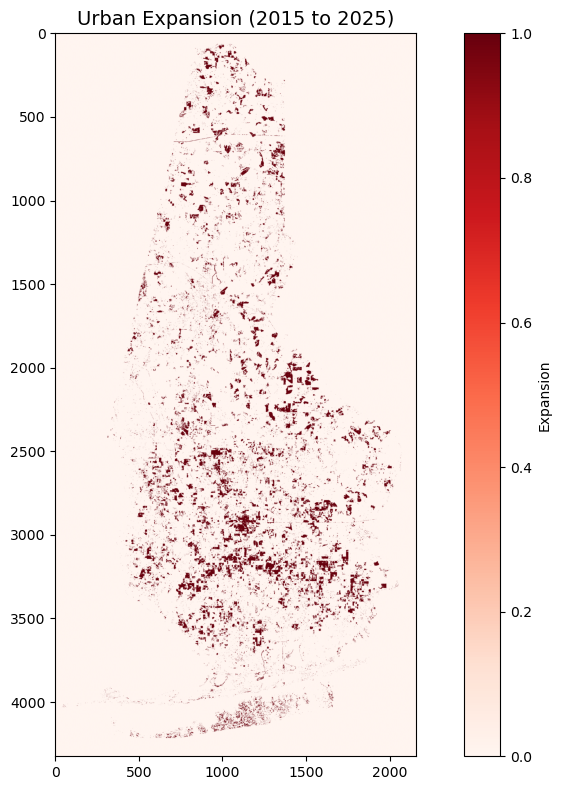

In [30]:
urban_expansion = (classified_maps[2015] == 0) & (classified_maps[2025] == 1) # & operator basically looks for pixels that were classified as vegetation (0) in 2015 and then changed to urban (1) in 2025, which indicates urban expansion.
plt.figure(figsize=(10, 8))
plt.imshow(urban_expansion, cmap="Reds")
plt.title("Urban Expansion (2015 to 2025)", fontsize=14)
plt.colorbar(label="Expansion")
plt.tight_layout()
plt.show()